# Bayesian Neural Network for Cytotoxicity Prediction with Uncertainty Quantification

This notebook trains a Bayesian Neural Network (BNN) using stochastic variational inference to predict metal-oxide nanoparticle cytotoxicity, on the larger complete-case dataset. The workflow includes: descriptor preprocessing consistent with the deterministic pipelines, a group-aware train/test split, training of a point-estimate guide used only as an optimization diagnostic, training of a mean-field Gaussian guide from which every reported metric and every uncertainty estimate is genuinely sampled, calibration analysis, and an end-to-end demonstration of a two-step screening-and-triage pipeline on a single shared test set.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import warnings
warnings.filterwarnings('ignore')

random.seed(42)
np.random.seed(42)
RANDOM_SEED = 42


## 1. Data loading and complete-case analysis

In [2]:
DATA_PATH = "NanoTox__unidas.csv"
df_raw = pd.read_csv(DATA_PATH)
print(f"Raw rows: {len(df_raw)}")

df = df_raw.dropna()
print(f"Complete-case rows: {len(df)}  Rows removed for missing values: {len(df_raw) - len(df)}")
df.describe()


Raw rows: 1482
Complete-case rows: 1363  Rows removed for missing values: 119


,hydrosize,surfcharge,surfarea,Ec,Expotime,dosage,e,NOxygen,class
count,1363.000000,1363.000000,1363.000000,1363.000000,1363.000000,1363.000000,1363.000000,1363.000000,1363.000000
mean,220.403448,0.048423,46.777021,-4.013191,26.117388,37.742507,1.636889,1.393984,0.406456
std,323.285979,25.010010,51.341579,0.531168,19.347339,40.477966,0.089429,0.585828,0.491352
min,7.500000,-41.600000,7.000000,-5.170000,3.000000,0.000010,1.540000,1.000000,0.000000
25%,35.600000,-11.700000,20.000000,-4.160000,12.000000,6.250000,1.540000,1.000000,0.000000
50%,100.000000,-10.000000,27.900000,-3.890000,24.000000,25.000000,1.650000,1.000000,0.000000
75%,273.400000,27.400000,50.000000,-3.890000,24.000000,50.000000,1.650000,2.000000,1.000000
max,1843.000000,42.800000,210.000000,-1.510000,72.000000,300.000000,1.900000,3.000000,1.000000


## 2. Descriptor transformations

The same variable-specific transformations used in the deterministic pipelines are applied here before scaling: logarithmic transforms, z-score standardization of surface charge, an offset logarithm for conduction band energy, base-10 logarithm for dosage, and a log2 transform for exposure time.

In [3]:
from sklearn.preprocessing import StandardScaler

features = ['hydrosize','surfcharge','surfarea','Ec','Expotime','dosage','e','NOxygen']

def normalise(df):
    df = df.copy()
    df['hydrosize'] = np.log(df['hydrosize'])
    df['surfarea'] = np.log(df['surfarea'])
    df['surfcharge'] = StandardScaler().fit_transform(df[['surfcharge']])
    df['Ec'] = np.log(6.17 + df['Ec'])
    df['dosage'] = np.log10(df['dosage'])
    df['Expotime'] = np.log(df['Expotime'] / 3) / np.log(2)
    df['e'] = np.log(df['e'])
    return df

df['_group_key'] = df[features].astype(str).agg('|'.join, axis=1)
n_groups = df['_group_key'].nunique()
print(f"Rows: {len(df)}  Unique experimental conditions: {n_groups}")
print(f"Rows sharing at least one technical replicate: {df.duplicated(subset=features, keep=False).sum()}")

df_norm = normalise(df)
df_norm['_group_key'] = df['_group_key'].values
df_norm[features].describe()


Rows: 1363  Unique experimental conditions: 690
Rows sharing at least one technical replicate: 940


,hydrosize,surfcharge,surfarea,Ec,Expotime,dosage,e,NOxygen
count,1363.000000,1.363000e+03,1363.000000,1363.000000,1363.000000,1363.000000,1363.000000,1363.000000
mean,4.599737,2.085232e-17,3.432568,0.739024,2.700777,0.707896,0.491373,1.393984
std,1.262094,1.000367e+00,0.871579,0.250689,1.194785,1.922344,0.052812,0.585828
min,2.014903,-1.665881e+00,1.945910,0.000000,0.000000,-5.000000,0.431782,1.000000
25%,3.572346,-4.699212e-01,2.995732,0.698135,2.000000,0.795880,0.431782,1.000000
50%,4.605170,-4.019235e-01,3.328627,0.824175,3.000000,1.397940,0.500775,1.000000
75%,5.610936,1.094027e+00,3.912023,0.824175,3.000000,1.698970,0.500775,2.000000
max,7.519150,1.710006e+00,5.347108,1.539015,4.584963,2.477121,0.641854,3.000000


## 3. Group-aware train/test split

Samples are grouped by the unique experimental condition (the full descriptor vector), each group is assigned its majority class, and complete groups are split 80/20, stratified on the group-level class. The final scaler is fit on the training partition only.

In [4]:
from sklearn.model_selection import train_test_split

group_majority = df_norm.groupby('_group_key')['class'].agg(lambda s: s.mode().iloc[0])
groups = group_majority.index.values
group_labels = group_majority.values

train_groups, test_groups = train_test_split(
    groups, test_size=0.20, random_state=RANDOM_SEED, stratify=group_labels
)
train_groups, test_groups = set(train_groups), set(test_groups)

train_mask = df_norm['_group_key'].isin(train_groups)
test_mask = df_norm['_group_key'].isin(test_groups)
assert (train_mask | test_mask).all() and not (train_mask & test_mask).any()

X_train_raw = df_norm.loc[train_mask, features].values
y_train_raw = df_norm.loc[train_mask, 'class'].values
X_test_raw = df_norm.loc[test_mask, features].values
y_test_raw = df_norm.loc[test_mask, 'class'].values

final_scaler = StandardScaler()
X_train = final_scaler.fit_transform(X_train_raw)
X_test = final_scaler.transform(X_test_raw)
y_train, y_test = y_train_raw, y_test_raw

print(f"Train: {len(X_train)} rows (non-toxic={int((y_train==0).sum())}, toxic={int((y_train==1).sum())})")
print(f"Test:  {len(X_test)} rows (non-toxic={int((y_test==0).sum())}, toxic={int((y_test==1).sum())})")
print(f"Toxic prevalence in test set: {100*y_test.mean():.1f}%")


Train: 1120 rows (non-toxic=661, toxic=459)
Test:  243 rows (non-toxic=148, toxic=95)
Toxic prevalence in test set: 39.1%


In [5]:
import torch
import torch.nn as nn
import pyro
import pyro.distributions as dist
from pyro.nn import PyroModule, PyroSample
from pyro.infer import SVI, Trace_ELBO
from pyro.optim import Adam
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, roc_curve,
                              average_precision_score, precision_score, recall_score, f1_score)

torch.manual_seed(RANDOM_SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

X_train_tensor = torch.FloatTensor(X_train).to(device)
y_train_tensor = torch.FloatTensor(y_train).to(device)
X_test_tensor = torch.FloatTensor(X_test).to(device)
y_test_tensor = torch.FloatTensor(y_test).to(device)
INPUT_DIM = X_train_tensor.shape[1]


Device: cpu


## 4. Model definition

In [6]:
def model(X, y):
    dev = X.device
    fc1_w = pyro.sample("fc1_w", dist.Normal(torch.tensor(0., device=dev), torch.tensor(1., device=dev))
                         .expand([64, X.shape[1]]).to_event(2))
    fc1_b = pyro.sample("fc1_b", dist.Normal(torch.tensor(0., device=dev), torch.tensor(1., device=dev))
                         .expand([64]).to_event(1))
    fc2_w = pyro.sample("fc2_w", dist.Normal(torch.tensor(0., device=dev), torch.tensor(1., device=dev))
                         .expand([1, 64]).to_event(2))
    fc2_b = pyro.sample("fc2_b", dist.Normal(torch.tensor(0., device=dev), torch.tensor(1., device=dev))
                         .expand([1]).to_event(1))
    with pyro.plate("data", len(X)):
        h = torch.relu(torch.matmul(X, fc1_w.t()) + fc1_b)
        logits = torch.sigmoid(torch.matmul(h, fc2_w.t()) + fc2_b).squeeze(-1)
        pyro.sample("obs", dist.Bernoulli(logits), obs=y)

print(f"Bayesian Neural Network defined: {INPUT_DIM} -> 64 -> 1, device: {device}")


Bayesian Neural Network defined: 8 -> 64 -> 1, device: cpu


## 5. Point-estimate optimization diagnostic

Initial loss: 648.5168   Final loss: 608.9100


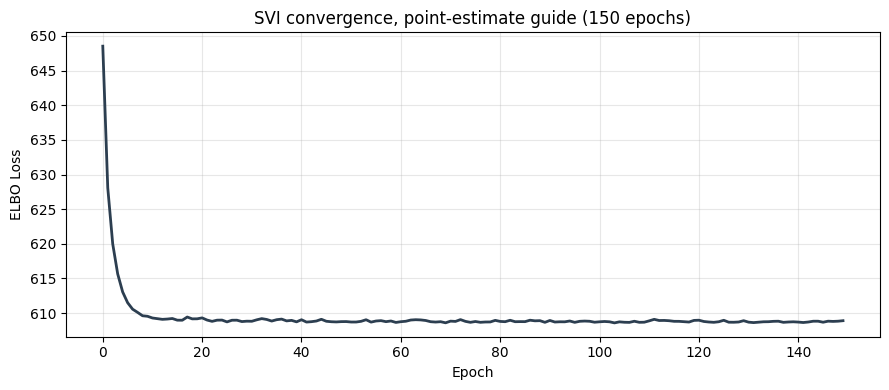

In [7]:
from pyro.infer.autoguide import AutoDelta

pyro.clear_param_store()
guide_auto = AutoDelta(model)
optimizer = Adam({"lr": 0.01})
svi = SVI(model, guide_auto, optimizer, loss=Trace_ELBO())

num_epochs = 150
batch_size = 64

X_init = X_train_tensor[:batch_size].cpu()
y_init = y_train_tensor[:batch_size].cpu()
guide_auto(X_init, y_init)
for name in pyro.get_param_store().keys():
    param = pyro.get_param_store()[name]
    pyro.get_param_store().replace_param(name, param.to(device), param)

losses = []
for epoch in range(num_epochs):
    indices = torch.randperm(len(X_train_tensor))
    X_shuf, y_shuf = X_train_tensor[indices], y_train_tensor[indices]
    epoch_loss, n_batches = 0, 0
    for i in range(0, len(X_shuf), batch_size):
        loss = svi.step(X_shuf[i:i+batch_size], y_shuf[i:i+batch_size])
        epoch_loss += loss; n_batches += 1
    losses.append(epoch_loss / n_batches)

print(f"Initial loss: {losses[0]:.4f}   Final loss: {losses[-1]:.4f}")
plt.figure(figsize=(9,4))
plt.plot(losses, linewidth=2, color='#2c3e50')
plt.xlabel('Epoch'); plt.ylabel('ELBO Loss'); plt.title('SVI convergence, point-estimate guide (150 epochs)')
plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig('fig4_10_elbo_convergence.png', dpi=300, bbox_inches='tight')
plt.show()


## 6. Point-estimate diagnostic evaluation

The point-estimate guide trained above is used here only to verify that a reasonable optimum is reachable on this architecture. The classification report printed below is a diagnostic check and is not used for any reported metric. All discriminative and uncertainty metrics reported later in this notebook are computed from the mean-field Gaussian guide trained in the next section.

In [8]:
fc1_w_m = guide_auto.median()["fc1_w"]; fc1_b_m = guide_auto.median()["fc1_b"]
fc2_w_m = guide_auto.median()["fc2_w"]; fc2_b_m = guide_auto.median()["fc2_b"]

with torch.no_grad():
    h_test = torch.relu(torch.matmul(X_test_tensor, fc1_w_m.t()) + fc1_b_m)
    y_pred_proba = torch.sigmoid(torch.matmul(h_test, fc2_w_m.t()) + fc2_b_m).squeeze(-1)
    y_pred_proba_np = y_pred_proba.cpu().numpy()
    y_pred = (y_pred_proba_np >= 0.5).astype(int)
    y_test_np = y_test_tensor.cpu().numpy().astype(int)

print(classification_report(y_test_np, y_pred, target_names=['Non-Toxic','Toxic']))
cm = confusion_matrix(y_test_np, y_pred)
print("Confusion matrix:\n", cm)


              precision    recall  f1-score   support

   Non-Toxic       0.96      0.89      0.92       148
       Toxic       0.84      0.95      0.89        95

    accuracy                           0.91       243
   macro avg       0.90      0.92      0.91       243
weighted avg       0.92      0.91      0.91       243

Confusion matrix:
 [[131  17]
 [  5  90]]


## 7. Mean-field Gaussian guide and posterior sampling

A mean-field Gaussian (AutoNormal) guide is trained for the same number of epochs as the point-estimate guide. Two hundred samples are then drawn genuinely from this trained posterior for every test instance; the mean of these samples is used as the predictive probability for classification, and their standard deviation is used as the epistemic uncertainty estimate. Both the classification metrics and the uncertainty estimates reported in the rest of this notebook come from this single guide.

In [9]:
from pyro.infer.autoguide import AutoNormal

pyro.clear_param_store()
guide_normal = AutoNormal(model)
optimizer_normal = Adam({"lr": 0.01})
svi_normal = SVI(model, guide_normal, optimizer_normal, loss=Trace_ELBO())

guide_normal(X_init.to(device), y_init.to(device))

for epoch in range(150):
    indices = torch.randperm(len(X_train_tensor))
    X_shuf, y_shuf = X_train_tensor[indices], y_train_tensor[indices]
    for i in range(0, len(X_shuf), 64):
        svi_normal.step(X_shuf[i:i+64], y_shuf[i:i+64])

num_samples = 200
predictions_samples = []
for _ in range(num_samples):
    with torch.no_grad():
        trace = pyro.poutine.trace(guide_normal).get_trace(X_test_tensor, y_test_tensor)
        w1 = trace.nodes['fc1_w']['value']
        b1 = trace.nodes['fc1_b']['value']
        w2 = trace.nodes['fc2_w']['value']
        b2 = trace.nodes['fc2_b']['value']
        h = torch.relu(torch.matmul(X_test_tensor, w1.t()) + b1)
        pred = torch.sigmoid(torch.matmul(h, w2.t()) + b2).squeeze(-1)
        predictions_samples.append(pred.cpu().numpy())

predictions_samples = np.array(predictions_samples)
y_pred_mean = predictions_samples.mean(axis=0)
y_pred_std = predictions_samples.std(axis=0)

print(f"Overall mean uncertainty:    {y_pred_std.mean():.4f}")
print(f"Mean uncertainty, non-toxic: {y_pred_std[y_test_np==0].mean():.4f}")
print(f"Mean uncertainty, toxic:     {y_pred_std[y_test_np==1].mean():.4f}")
print(f"Maximum / minimum uncertainty: {y_pred_std.max():.4f} / {y_pred_std.min():.4f}")


Overall mean uncertainty:    0.2684
Mean uncertainty, non-toxic: 0.2776
Mean uncertainty, toxic:     0.2540
Maximum / minimum uncertainty: 0.4619 / 0.1254


## 8. Discriminative performance

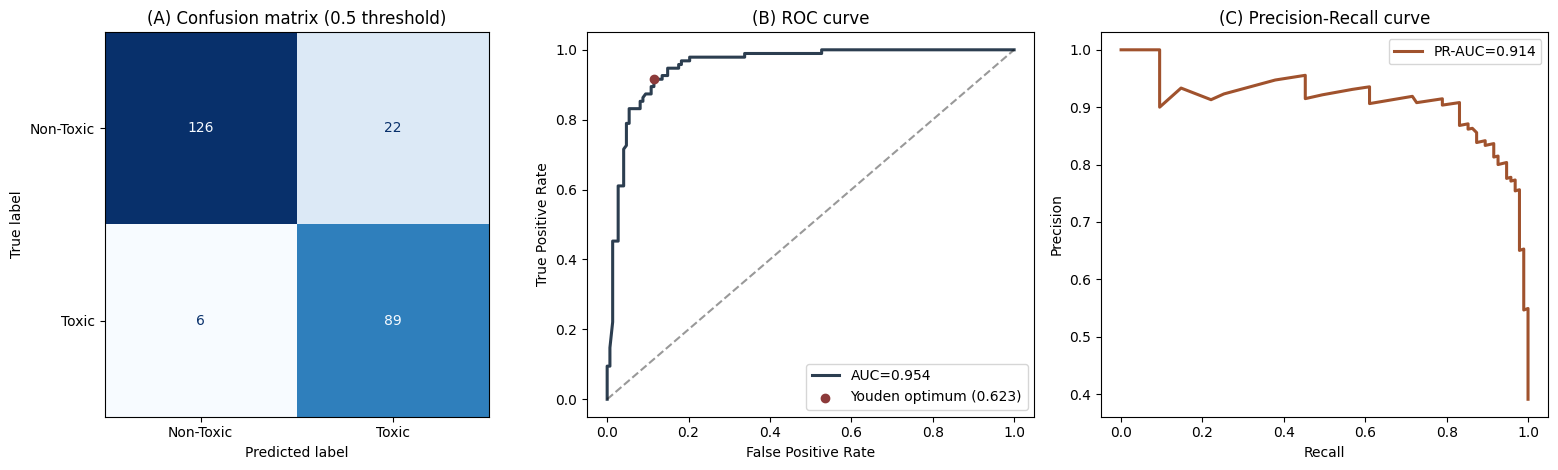

              precision    recall  f1-score   support

   Non-Toxic       0.95      0.85      0.90       148
       Toxic       0.80      0.94      0.86        95

    accuracy                           0.88       243
   macro avg       0.88      0.89      0.88       243
weighted avg       0.89      0.88      0.89       243



In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve
from sklearn.metrics import roc_curve as _roc

y_pred_final = (y_pred_mean >= 0.5).astype(int)
cm_bnn = confusion_matrix(y_test_np, y_pred_final)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

disp = ConfusionMatrixDisplay(confusion_matrix=cm_bnn, display_labels=['Non-Toxic','Toxic'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('(A) Confusion matrix (0.5 threshold)')

fpr_bnn, tpr_bnn, thr_bnn = _roc(y_test_np, y_pred_mean)
roc_auc_bnn = roc_auc_score(y_test_np, y_pred_mean)
youden_idx = np.argmax(tpr_bnn - fpr_bnn)
youden = thr_bnn[youden_idx]
axes[1].plot(fpr_bnn, tpr_bnn, linewidth=2.2, color='#2c3e50', label=f'AUC={roc_auc_bnn:.3f}')
axes[1].scatter([fpr_bnn[youden_idx]], [tpr_bnn[youden_idx]], color='#8c3a3a', zorder=5, label=f'Youden optimum ({youden:.3f})')
axes[1].plot([0,1],[0,1],'k--',alpha=0.4)
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('(B) ROC curve'); axes[1].legend()

prec_bnn, rec_bnn, _ = precision_recall_curve(y_test_np, y_pred_mean)
pr_auc_bnn = average_precision_score(y_test_np, y_pred_mean)
axes[2].plot(rec_bnn, prec_bnn, linewidth=2.2, color='#a0522d', label=f'PR-AUC={pr_auc_bnn:.3f}')
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')
axes[2].set_title('(C) Precision-Recall curve'); axes[2].legend()

plt.tight_layout()
plt.savefig('fig5_10_bnn_performance.png', dpi=300, bbox_inches='tight')
plt.show()

print(classification_report(y_test_np, y_pred_final, target_names=['Non-Toxic','Toxic']))


## 9. Uncertainty-accuracy relationship and high-uncertainty threshold

In [11]:
threshold_hi = y_pred_std.mean() + y_pred_std.std()
n_high = int((y_pred_std > threshold_hi).sum())
print(f"High-uncertainty threshold (mean + 1 sd): {threshold_hi:.4f}")
print(f"High-uncertainty instances: {n_high} of {len(y_pred_std)} ({100*n_high/len(y_pred_std):.1f}%)")

acc_pred = (y_pred_mean >= 0.5).astype(int)
correct = (acc_pred == y_test_np).astype(int)
bins = np.quantile(y_pred_std, np.linspace(0, 1, 6))
bin_ids = np.digitize(y_pred_std, bins[1:-1])
bin_acc, bin_unc = [], []
for b in range(bin_ids.max()+1):
    mask = bin_ids == b
    if mask.sum() > 0:
        bin_acc.append(correct[mask].mean())
        bin_unc.append(y_pred_std[mask].mean())
from scipy.stats import pearsonr
r, p = pearsonr(bin_unc, bin_acc)
print(f"Binned uncertainty-accuracy correlation: r={r:.2f}, p={p:.2f}")


High-uncertainty threshold (mean + 1 sd): 0.3512
High-uncertainty instances: 56 of 243 (23.0%)
Binned uncertainty-accuracy correlation: r=-0.94, p=0.02


## 10. Uncertainty quantification, full view

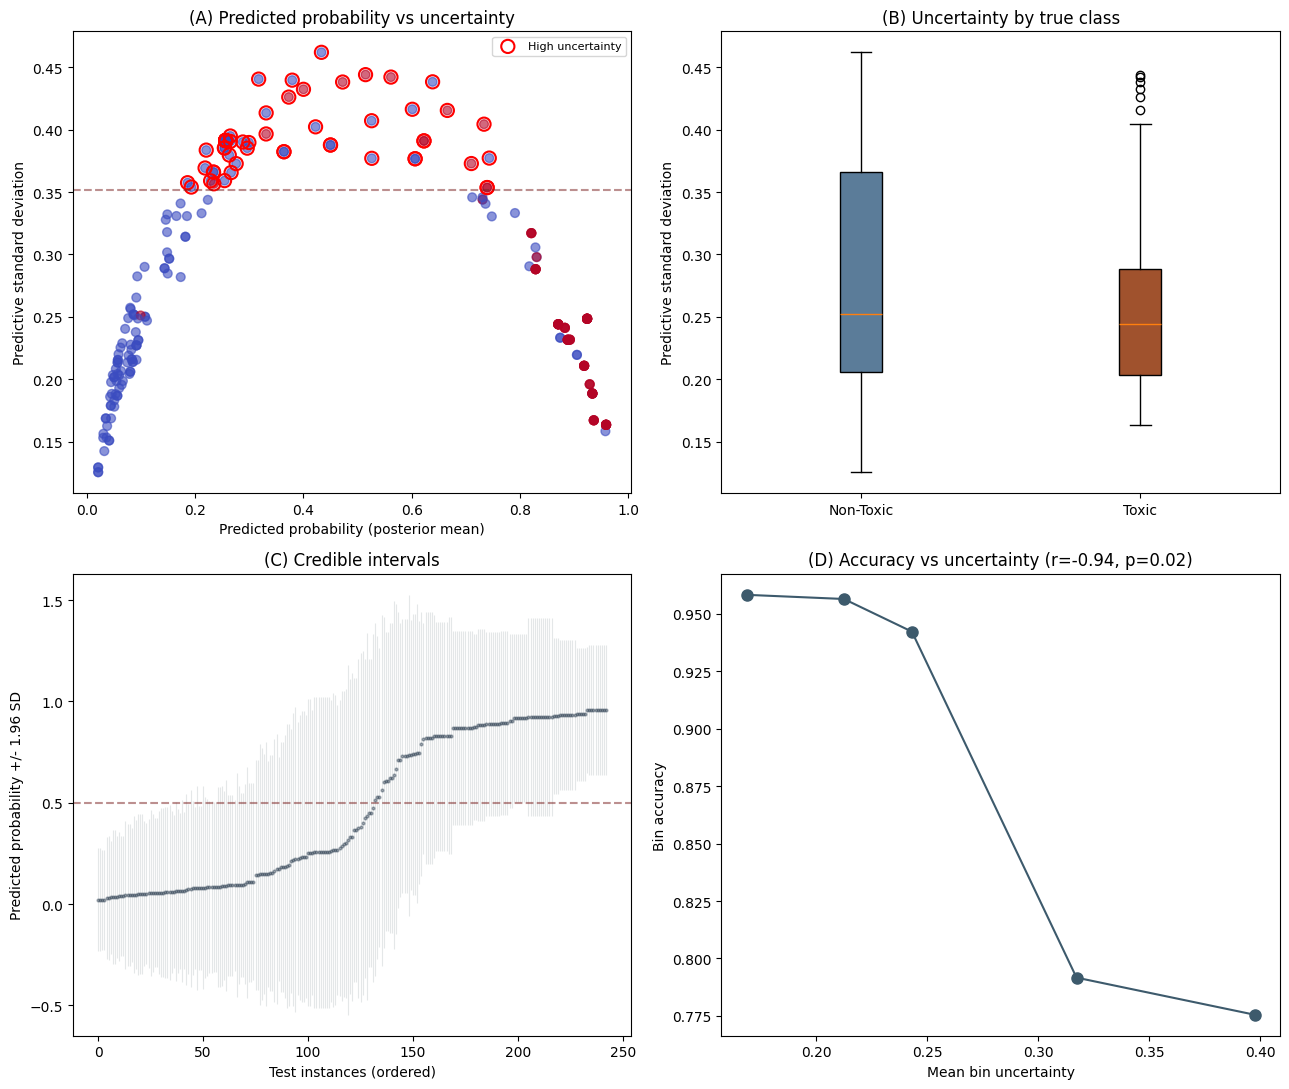

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(13, 11))

sc = axes[0,0].scatter(y_pred_mean, y_pred_std, c=y_test_np, cmap='coolwarm', alpha=0.6, s=40)
hi = y_pred_std > threshold_hi
axes[0,0].scatter(y_pred_mean[hi], y_pred_std[hi], facecolors='none', edgecolors='red', s=90, linewidths=1.5, label='High uncertainty')
axes[0,0].axhline(threshold_hi, color='#7a2020', linestyle='--', alpha=0.5)
axes[0,0].set_xlabel('Predicted probability (posterior mean)'); axes[0,0].set_ylabel('Predictive standard deviation')
axes[0,0].set_title('(A) Predicted probability vs uncertainty'); axes[0,0].legend(fontsize=8)

box_data = [y_pred_std[y_test_np==0], y_pred_std[y_test_np==1]]
bp = axes[0,1].boxplot(box_data, labels=['Non-Toxic','Toxic'], patch_artist=True)
for patch, c in zip(bp['boxes'], ['#5b7c99', '#a0522d']):
    patch.set_facecolor(c)
axes[0,1].set_ylabel('Predictive standard deviation')
axes[0,1].set_title('(B) Uncertainty by true class')

order = np.argsort(y_pred_mean)
axes[1,0].errorbar(range(len(order)), y_pred_mean[order], yerr=1.96*y_pred_std[order],
                    fmt='o', markersize=2, alpha=0.4, color='#2c3e50', ecolor='#bdc3c7', elinewidth=0.8)
axes[1,0].axhline(0.5, color='#7a2020', linestyle='--', alpha=0.5)
axes[1,0].set_xlabel('Test instances (ordered)'); axes[1,0].set_ylabel('Predicted probability +/- 1.96 SD')
axes[1,0].set_title('(C) Credible intervals')

from scipy.stats import pearsonr as _pearsonr_fig
r_unc, p_unc = _pearsonr_fig(bin_unc, bin_acc)
axes[1,1].plot(bin_unc, bin_acc, 'o-', color='#3d5a6c', markersize=8)
axes[1,1].set_xlabel('Mean bin uncertainty'); axes[1,1].set_ylabel('Bin accuracy')
axes[1,1].set_title(f'(D) Accuracy vs uncertainty (r={r_unc:.2f}, p={p_unc:.2f})')

plt.tight_layout()
plt.savefig('fig5_11_uncertainty_quantification.png', dpi=300, bbox_inches='tight')
plt.show()


## 11. Calibration

The Expected Calibration Error (ECE) compares the predicted probability in each bin against the observed fraction of positive outcomes in that bin, weighted by the number of samples per bin.

Expected Calibration Error (10 bins): 0.0843


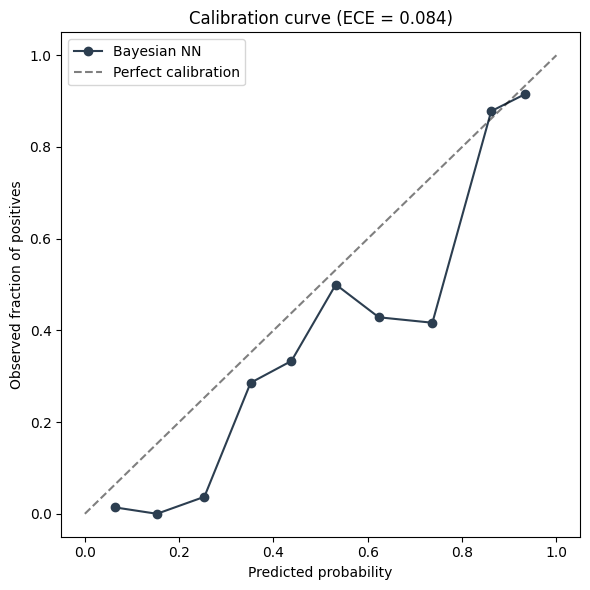

In [13]:
from sklearn.calibration import calibration_curve

n_bins = 10
prob_true, prob_pred = calibration_curve(y_test_np, y_pred_mean, n_bins=n_bins, strategy='uniform')

bin_edges = np.linspace(0, 1, n_bins + 1)
bin_idx = np.digitize(y_pred_mean, bin_edges[1:-1])
ece = 0.0
for b in range(n_bins):
    mask = bin_idx == b
    if mask.sum() == 0:
        continue
    frac_pos_bin = y_test_np[mask].mean()
    conf_bin = y_pred_mean[mask].mean()
    ece += (mask.sum() / len(y_pred_mean)) * abs(frac_pos_bin - conf_bin)

print(f"Expected Calibration Error ({n_bins} bins): {ece:.4f}")

fig, ax = plt.subplots(figsize=(6,6))
ax.plot(prob_pred, prob_true, 'o-', color='#2c3e50', label='Bayesian NN')
ax.plot([0,1],[0,1],'k--', alpha=0.5, label='Perfect calibration')
ax.set_xlabel('Predicted probability'); ax.set_ylabel('Observed fraction of positives')
ax.set_title(f'Calibration curve (ECE = {ece:.3f})')
ax.legend()
plt.tight_layout()
plt.savefig('fig5_12_calibration.png', dpi=300, bbox_inches='tight')
plt.show()


## 12. Summary table

In [14]:
precision_toxic = precision_score(y_test_np, (y_pred_mean>=0.5).astype(int), pos_label=1)
recall_toxic = recall_score(y_test_np, (y_pred_mean>=0.5).astype(int), pos_label=1)
f1_toxic = f1_score(y_test_np, (y_pred_mean>=0.5).astype(int), pos_label=1)
tn, fp, fn, tp = confusion_matrix(y_test_np, (y_pred_mean>=0.5).astype(int)).ravel()
specificity = tn / (tn+fp)

summary = pd.DataFrame({
    'Metric': ['Test set size', 'Non-toxic', 'Toxic', 'ROC-AUC', 'PR-AUC', 'Recall', 'Specificity',
               'Precision', 'F1', 'Youden threshold', 'ECE',
               'Mean uncertainty, overall', 'Mean uncertainty, non-toxic', 'Mean uncertainty, toxic',
               'High-uncertainty instances', 'Uncertainty-accuracy correlation'],
    'Value': [len(y_test_np), int((y_test_np==0).sum()), int((y_test_np==1).sum()),
              round(roc_auc_score(y_test_np, y_pred_mean),3), round(average_precision_score(y_test_np, y_pred_mean),3),
              round(recall_toxic,3), round(specificity,3), round(precision_toxic,3), round(f1_toxic,3),
              round(float(youden),3), round(ece,3),
              round(y_pred_std.mean(),3), round(y_pred_std[y_test_np==0].mean(),3), round(y_pred_std[y_test_np==1].mean(),3),
              n_high, round(r,2)]
})
summary.to_csv('bnn_summary.csv', index=False)
summary


,Metric,Value
0,Test set size,243.000
1,Non-toxic,148.000
2,Toxic,95.000
3,ROC-AUC,0.954
4,PR-AUC,0.914
5,Recall,0.937
6,Specificity,0.851
7,Precision,0.802
8,F1,0.864
9,Youden threshold,0.623


## 13. Comparison against Logistic Regression, Random Forest, SVM and MLP

Random Forest, Logistic Regression, an MLP, and a linear SVM are trained on the same group-aware split used for the Bayesian Neural Network, and evaluated on three criteria fixed in advance: ROC-AUC for discrimination, and log-loss and Brier score for the calibration of the predicted probabilities.

In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, brier_score_loss

baseline_models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED),
    'SVM (linear)': SVC(kernel='linear', probability=True, random_state=RANDOM_SEED, class_weight='balanced'),
    'MLP': MLPClassifier(hidden_layer_sizes=(64,), max_iter=1000, random_state=RANDOM_SEED),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_SEED),
}

comparison_rows = []
bnn_ll = log_loss(y_test_np, np.clip(y_pred_mean, 1e-7, 1-1e-7))
bnn_brier = brier_score_loss(y_test_np, y_pred_mean)
bnn_roc = roc_auc_score(y_test_np, y_pred_mean)
comparison_rows.append(['Bayesian NN', bnn_roc, bnn_ll, bnn_brier])

for name, clf in baseline_models.items():
    clf.fit(X_train, y_train)
    p = clf.predict_proba(X_test)[:, 1]
    comparison_rows.append([
        name,
        roc_auc_score(y_test_np, p),
        log_loss(y_test_np, np.clip(p, 1e-7, 1-1e-7)),
        brier_score_loss(y_test_np, p)
    ])

fig513 = pd.DataFrame(comparison_rows, columns=['Method','ROC-AUC','Log-Loss','Brier']).round(3)
fig513.to_csv('model_comparison.csv', index=False)
print(fig513.to_string(index=False))


             Method  ROC-AUC  Log-Loss  Brier
        Bayesian NN    0.954     0.308  0.090
      Random Forest    0.993     0.114  0.035
       SVM (linear)    0.968     0.230  0.065
                MLP    0.991     0.115  0.032
Logistic Regression    0.970     0.222  0.065


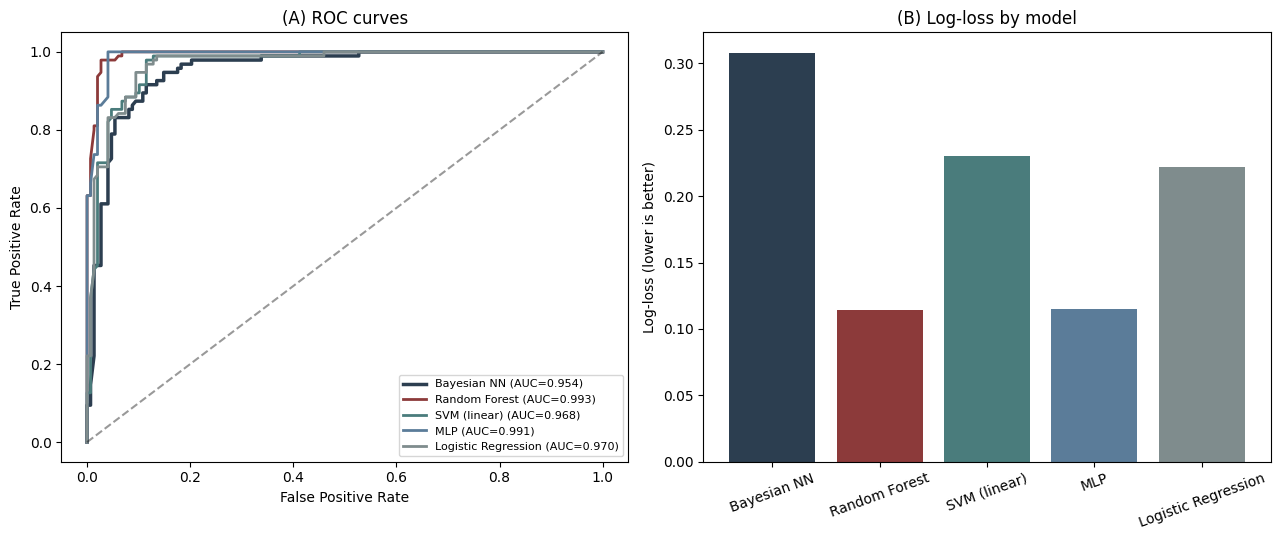

Best ROC-AUC: Random Forest (0.993)
Best log-loss: Random Forest (0.114)
Best Brier score: MLP (0.032)


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
palette = ["#8c3a3a", "#4a7c7c", "#5b7c99", "#7f8c8d"]

axes[0].plot(*_roc(y_test_np, y_pred_mean)[:2], linewidth=2.5, color='#2c3e50', label=f'Bayesian NN (AUC={bnn_roc:.3f})')
for i, (name, clf) in enumerate(baseline_models.items()):
    p = clf.predict_proba(X_test)[:, 1]
    fpr_c, tpr_c, _ = _roc(y_test_np, p)
    axes[0].plot(fpr_c, tpr_c, linewidth=2, color=palette[i % len(palette)], label=f'{name} (AUC={roc_auc_score(y_test_np,p):.3f})')
axes[0].plot([0,1],[0,1],'k--', alpha=0.4)
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('(A) ROC curves'); axes[0].legend(loc='lower right', fontsize=8)

axes[1].bar(fig513['Method'], fig513['Log-Loss'], color=["#2c3e50", "#8c3a3a", "#4a7c7c", "#5b7c99", "#7f8c8d"][:len(fig513)])
axes[1].set_ylabel('Log-loss (lower is better)')
axes[1].set_title('(B) Log-loss by model')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('fig5_13_bnn_vs_all_methods.png', dpi=300, bbox_inches='tight')
plt.show()

best_auc = fig513.loc[fig513['ROC-AUC'].idxmax()]
best_ll = fig513.loc[fig513['Log-Loss'].idxmin()]
best_brier = fig513.loc[fig513['Brier'].idxmin()]
print(f"Best ROC-AUC: {best_auc['Method']} ({best_auc['ROC-AUC']:.3f})")
print(f"Best log-loss: {best_ll['Method']} ({best_ll['Log-Loss']:.3f})")
print(f"Best Brier score: {best_brier['Method']} ({best_brier['Brier']:.3f})")


## 14. Two-step pipeline demonstration on a shared test set

A high-recall linear SVM screen is trained on the same training partition as the Bayesian Neural Network and applied to the same 243-instance test set. Its positive calls are then cross-referenced against the BNN's high-uncertainty flags on that same test set, so that both steps of the pipeline are evaluated on identical data.

In [17]:
from sklearn.svm import SVC

svm_screen = SVC(kernel='linear', probability=True, random_state=RANDOM_SEED, class_weight='balanced')
svm_screen.fit(X_train, y_train)
svm_pred = svm_screen.predict(X_test)
svm_prob = svm_screen.predict_proba(X_test)[:, 1]

svm_recall = recall_score(y_test_np, svm_pred, pos_label=1)
svm_fnr = 1 - svm_recall
tn_s, fp_s, fn_s, tp_s = confusion_matrix(y_test_np, svm_pred).ravel()
print(f"Screening step, SVM on the shared test set (n={len(y_test_np)}):")
print(f"  Recall (toxic) = {svm_recall:.3f}   FNR = {svm_fnr:.3f}   (TN={tn_s}, FP={fp_s}, FN={fn_s}, TP={tp_s})")
print(f"  Instances flagged as toxic by the SVM: {svm_pred.sum()} of {len(svm_pred)}")


Screening step, SVM on the shared test set (n=243):
  Recall (toxic) = 0.979   FNR = 0.021   (TN=129, FP=19, FN=2, TP=93)
  Instances flagged as toxic by the SVM: 112.0 of 243


In [18]:
flagged_by_svm = svm_pred == 1
high_uncertainty = y_pred_std > threshold_hi

n_flagged = flagged_by_svm.sum()
n_flagged_and_uncertain = (flagged_by_svm & high_uncertainty).sum()
n_uncertain_missed_by_svm = ((~flagged_by_svm) & high_uncertainty).sum()

print(f"Triage step, BNN uncertainty over the SVM-flagged instances:")
print(f"  Instances flagged by the SVM (step 1): {n_flagged}")
print(f"  Of those, also flagged as high-uncertainty by the BNN: {n_flagged_and_uncertain} ({100*n_flagged_and_uncertain/n_flagged:.1f}%)")
print(f"  High-uncertainty instances not flagged by the SVM: {n_uncertain_missed_by_svm}")
print(f"  Total high-uncertainty instances: {high_uncertainty.sum()}")

pipeline_summary = pd.DataFrame({
    'Stage': ['Full test set', 'Flagged toxic by SVM (step 1)',
              'Of those, high-uncertainty by BNN (step 2, highest priority)',
              'High-uncertainty but missed by the SVM screen'],
    'n': [len(y_test_np), int(n_flagged), int(n_flagged_and_uncertain), int(n_uncertain_missed_by_svm)]
})
pipeline_summary.to_csv('two_step_pipeline_summary.csv', index=False)
pipeline_summary


Triage step, BNN uncertainty over the SVM-flagged instances:
  Instances flagged by the SVM (step 1): 112
  Of those, also flagged as high-uncertainty by the BNN: 18 (16.1%)
  High-uncertainty instances not flagged by the SVM: 38
  Total high-uncertainty instances: 56


,Stage,n
0,Full test set,243
1,Flagged toxic by SVM (step 1),112
2,"Of those, high-uncertainty by BNN (step 2, hig...",18
3,High-uncertainty but missed by the SVM screen,38
